## Modelagem do Perceptron

In [1]:
import numpy as np

In [2]:
class Perceptron:
    def __init__(self, input_size, eta=0.1, epochs=1000):
        self.w = np.zeros(input_size)
        self.b = 0
        self.eta = eta
        self.epochs = epochs

    def getParam(self):
        return {'w': self.w, 'b': self.b}

    def sigma(self, v):
        return 1 if v >= 0 else 0

    def predict(self, x):
        return self.sigma(np.dot(self.w, x) + self.b)

    def train(self, X, y):
        for _ in range(self.epochs):
            for x, y_true in zip(X, y):
                y_hat = self.predict(x)
                temp = self.eta * (y_true - y_hat) # se repete em w e b
                self.w += temp * x
                self.b += temp

In [3]:
p = Perceptron(input_size=2)

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

p.train(X,y)

for x, y_true in zip(X,y):
      y_hat = p.predict(x)
      print(f"x: {x} y_true: {y_true} y_hat: {y_hat}")

x: [0 0] y_true: 0 y_hat: 1
x: [0 1] y_true: 1 y_hat: 1
x: [1 0] y_true: 1 y_hat: 0
x: [1 1] y_true: 0 y_hat: 0


## Multilayer Perceptron

In [4]:
import numpy as np

In [5]:
u = [1,2,3]
v = [4,5,6]

np.outer(u,v)

array([[ 4,  5,  6],
       [ 8, 10, 12],
       [12, 15, 18]])

In [6]:
import matplotlib.pyplot as plt

# Função de ativação sigmoide e sua derivada
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)  # Derivada da sigmoide

# Função para visualizar a fronteira de decisão
def plot_decision_boundary(model, X, y):
    # h é o passo para formar a grade
    # Criar uma grade de pontos no espaço de entrada
    #x_min, x_max = -0.2, 1.2
    #y_min, y_max = -0.2, 1.2
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

    # Prever a saída para cada ponto da grade
    Z = np.array([model.predict(np.array([x, y])) for x, y in zip(xx.ravel(), yy.ravel())])
    Z = Z.reshape(xx.shape)

    # Criar o gráfico da fronteira de decisão
    plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.coolwarm)

    # Adicionar pontos de entrada reais
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm, s=10, alpha=0.5)
    plt.xlabel("Entrada 1")
    plt.ylabel("Entrada 2")
    plt.title("Fronteiras de Decisão")
    plt.show()


class MLP:
    def __init__(self, input_size, hidden_size, output_size, eta=0.1, epochs=10000):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.eta = eta
        self.epochs = epochs

        # Inicialização dos pesos e bias com valores aleatórios pequenos
        self.w1 = np.random.uniform(-1, 1, (self.hidden_size, self.input_size))
        self.b1 = np.random.uniform(-1, 1, self.hidden_size)
        self.w2 = np.random.uniform(-1, 1, (self.output_size, self.hidden_size))
        self.b2 = np.random.uniform(-1, 1, self.output_size)

    def forward(self, x):
        """Propagação direta"""
        self.z1 = np.dot(self.w1, x) + self.b1
        self.a1 = sigmoid(self.z1)  # Ativação da camada oculta
        self.z2 = np.dot(self.w2, self.a1) + self.b2
        self.a2 = sigmoid(self.z2)  # Saída final
        return self.a2

    def backward(self, x, y_true):
        """Retropropagação do erro"""
        # Erro na saída
        erro = y_true - self.a2
        d_output = erro * sigmoid_derivative(self.a2)

        # Erro na camada oculta
        erro_hidden = np.dot(self.w2.T, d_output)
        d_hidden = erro_hidden * sigmoid_derivative(self.a1)

        # Atualização dos pesos e bias da camada de saída
        self.w2 += self.eta * np.outer(d_output, self.a1)
        self.b2 += self.eta * d_output

        # Atualização dos pesos e bias da camada oculta
        self.w1 += self.eta * np.outer(d_hidden, x)
        self.b1 += self.eta * d_hidden

    def train(self, X, y):
        """Treinamento da MLP"""
        for _ in range(self.epochs):
            for x, y_true in zip(X, y):
                x = np.array(x)  # Garantir que x é um array
                y_true = np.array([y_true])  # Transformar em vetor
                self.forward(x)
                self.backward(x, y_true)

    def predict(self, x):
        """Fazer uma previsão"""
        output = self.forward(x)
        return 1 if output >= 0.5 else 0  # Aplicar threshold

## Porta OR

x: [0 0] -> y_true: 0, y_hat: 0
x: [0 1] -> y_true: 1, y_hat: 1
x: [1 0] -> y_true: 1, y_hat: 1
x: [1 1] -> y_true: 1, y_hat: 1


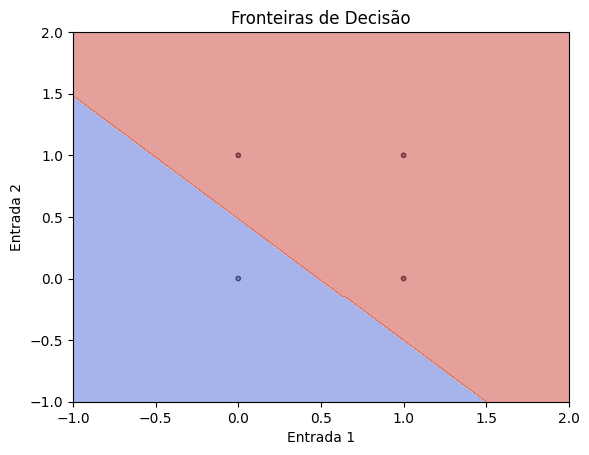

In [7]:
# Definição dos dados de entrada e saída esperada (XOR)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 1, 1, 1])

# Criando a MLP (2 neurônios de entrada, 2 ocultos, 1 de saída)
mlp = MLP(input_size=2, hidden_size=2, output_size=1, eta=0.1, epochs=10000)

# Treinamento
mlp.train(X, y)

# Teste do modelo treinado
for x, y_true in zip(X, y):
    y_hat = mlp.predict(x)
    print(f"x: {x} -> y_true: {y_true}, y_hat: {y_hat}")

# Visualizar as fronteiras de decisão
plot_decision_boundary(mlp, X, y)

## Porta AND

x: [0 0] -> y_true: 0, y_hat: 0
x: [0 1] -> y_true: 0, y_hat: 0
x: [1 0] -> y_true: 0, y_hat: 0
x: [1 1] -> y_true: 1, y_hat: 1


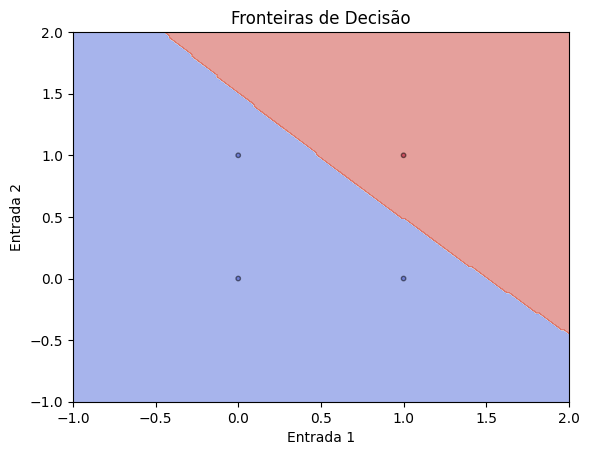

In [8]:
# Definição dos dados de entrada e saída esperada (XOR)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])

# Criando a MLP (2 neurônios de entrada, 2 ocultos, 1 de saída)
mlp = MLP(input_size=2, hidden_size=2, output_size=1, eta=0.1, epochs=10000)

# Treinamento
mlp.train(X, y)

# Teste do modelo treinado
for x, y_true in zip(X, y):
    y_hat = mlp.predict(x)
    print(f"x: {x} -> y_true: {y_true}, y_hat: {y_hat}")

# Visualizar as fronteiras de decisão
plot_decision_boundary(mlp, X, y)

## Porta XOR

x: [0 0] -> y_true: 0, y_hat: 0
x: [0 1] -> y_true: 1, y_hat: 1
x: [1 0] -> y_true: 1, y_hat: 1
x: [1 1] -> y_true: 0, y_hat: 0


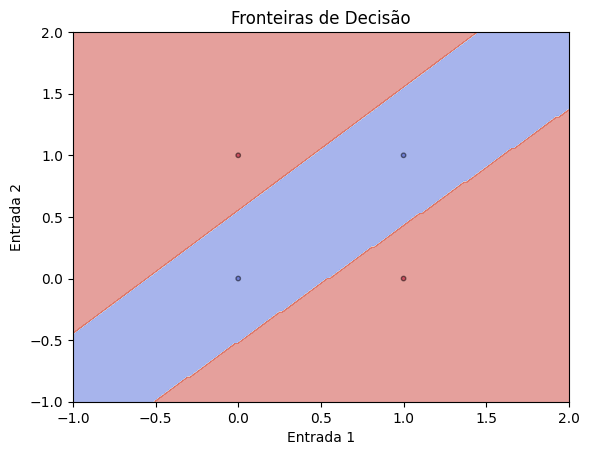

In [9]:
# Definição dos dados de entrada e saída esperada (XOR)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 1, 1, 0])

# Criando a MLP (2 neurônios de entrada, 2 ocultos, 1 de saída)
mlp = MLP(input_size=2, hidden_size=2, output_size=1, eta=0.1, epochs=10000)

# Treinamento
mlp.train(X, y)

# Teste do modelo treinado
for x, y_true in zip(X, y):
    y_hat = mlp.predict(x)
    print(f"x: {x} -> y_true: {y_true}, y_hat: {y_hat}")

# Visualizar as fronteiras de decisão
plot_decision_boundary(mlp, X, y)

x: [0 0] -> y_true: 0, y_hat: 0
x: [0 1] -> y_true: 1, y_hat: 1
x: [1 0] -> y_true: 1, y_hat: 1
x: [1 1] -> y_true: 0, y_hat: 0


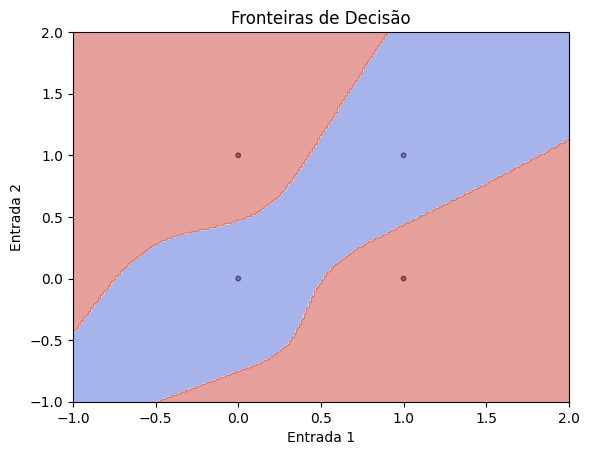

In [16]:
# Definição dos dados de entrada e saída esperada (XOR)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 1, 1, 0])

# Criando a MLP (2 neurônios de entrada, 2 ocultos, 1 de saída)
mlp = MLP(input_size=2, hidden_size=10, output_size=1, eta=0.1, epochs=10000)

# Treinamento
mlp.train(X, y)

# Teste do modelo treinado
for x, y_true in zip(X, y):
    y_hat = mlp.predict(x)
    print(f"x: {x} -> y_true: {y_true}, y_hat: {y_hat}")

# Visualizar as fronteiras de decisão
plot_decision_boundary(mlp, X, y)

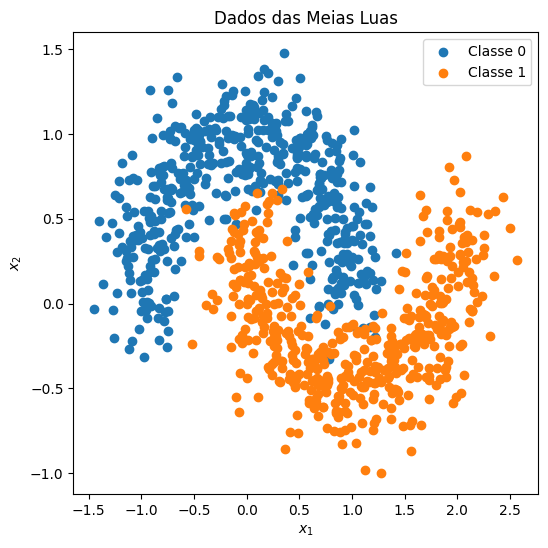

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Gerando dados das meias luas
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
#X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)

# Ajustando a escala para ficar mais parecido com a imagem
#X[:, 0] *= 5  # Alarga a distribuição
#X[:, 1] *= 6  # Aumenta a altura das luas

# Plotando os dados gerados
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Classe 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Classe 1")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Dados das Meias Luas")
plt.legend()
plt.show()

Acurácia: 0.98


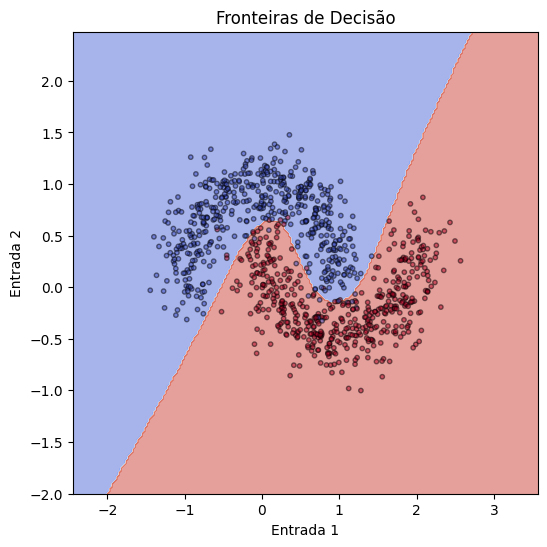

In [19]:
# Criando a MLP (2 neurônios de entrada, 5 ocultos, 1 de saída)
mlp = MLP(input_size=2, hidden_size=5, output_size=1, eta=0.1, epochs=1000)

# Treinamento da MLP com os dados das meias luas
mlp.train(X, y)

# Teste do modelo treinado
acertos = 0
for x, y_true in zip(X, y):
    y_hat = mlp.predict(x)
    if y_hat == y_true:
        acertos += 1

# Exibir acurácia do modelo
print(f"Acurácia: {acertos / len(y):.2f}")

plt.figure(figsize=(6, 6))
plot_decision_boundary(mlp, X, y)
